# 01. Khám phá dữ liệu Twitter Bot Detection Dataset

**Project:** `social-anomaly-clustering`  
**Đề tài:** Ứng dụng kỹ thuật gom nhóm trong phát hiện hành vi bất thường của người dùng mạng xã hội  
**Dataset:** `bot_detection_data.csv`

Notebook này trình bày bước **khám phá dữ liệu ban đầu** theo dạng báo cáo.  
Mục tiêu chính là hiểu cấu trúc dữ liệu, kiểm tra chất lượng dữ liệu, phân bố nhãn, phân bố các thuộc tính hành vi và xác định các đặc trưng có thể dùng cho bước tiền xử lý/gom nhóm.

> Lưu ý: Cột `Bot Label` chỉ được dùng để phân tích và đánh giá sau cùng. Không sử dụng cột này làm đầu vào cho các thuật toán gom nhóm như K-Means.


In [1]:
pip install pandas numpy seaborn matplotlib pyyaml


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Import thư viện và thiết lập đường dẫn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("../datasets/raw/bot_detection_data.csv")
FIGURE_DIR = Path("../results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Figure output path:", FIGURE_DIR)


Dataset path: ../datasets/raw/bot_detection_data.csv
Figure output path: ../results/figures


## 2. Đọc dữ liệu

In [4]:
df = pd.read_csv(DATA_PATH)

df.head()

,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majority none few size expect six marriage.,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff rate common protect attention.,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to goal range case.,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


## 3. Kích thước dữ liệu

Kiểm tra số dòng và số cột của dataset.


In [5]:
n_rows, n_cols = df.shape

print(f"Số dòng: {n_rows:,}")
print(f"Số cột: {n_cols}")

Số dòng: 50,000
Số cột: 11


**Nhận xét:**  
Bộ dữ liệu gồm **50,000 bản ghi** và **11 thuộc tính**. Mỗi bản ghi biểu diễn thông tin của một người dùng/tweet trên mạng xã hội Twitter/X.

Với kích thước này, dataset đủ lớn để thực hiện các kỹ thuật khai phá dữ liệu như phân tích thống kê, trích xuất đặc trưng và gom nhóm.


## 4. Danh sách thuộc tính

Kiểm tra tên các cột gốc trong dataset.


In [6]:
for idx, col in enumerate(df.columns, start=1):
    print(f"{idx}. {col}")

1. User ID
2. Username
3. Tweet
4. Retweet Count
5. Mention Count
6. Follower Count
7. Verified
8. Bot Label
9. Location
10. Created At
11. Hashtags


### 4.1. Ý nghĩa các thuộc tính

| Thuộc tính | Ý nghĩa dự kiến |
|---|---|
| `User ID` | Mã định danh người dùng |
| `Username` | Tên tài khoản |
| `Tweet` | Nội dung tweet |
| `Retweet Count` | Số lượt retweet |
| `Mention Count` | Số lượng mention trong tweet |
| `Follower Count` | Số lượng người theo dõi |
| `Verified` | Trạng thái xác minh tài khoản |
| `Bot Label` | Nhãn tài khoản: `0 = Human`, `1 = Bot` |
| `Location` | Vị trí người dùng khai báo |
| `Created At` | Thời điểm tạo bản ghi/tài khoản trong dataset |
| `Hashtags` | Danh sách hashtag hoặc cụm từ hashtag liên quan |

**Lưu ý:**  
Các tên cột gốc có dấu cách và chữ hoa, ví dụ `Retweet Count`, `Bot Label`.  
Ở bước tiền xử lý, nên đổi tên về dạng `snake_case`, ví dụ `retweet_count`, `bot_label`, để code dễ viết và dễ bảo trì hơn.


## 5. Kiểu dữ liệu của từng cột

Kiểm tra kiểu dữ liệu giúp xác định cột nào có thể dùng trực tiếp, cột nào cần chuyển đổi trước khi đưa vào mô hình.


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   User ID         50000 non-null  int64
 1   Username        50000 non-null  str  
 2   Tweet           50000 non-null  str  
 3   Retweet Count   50000 non-null  int64
 4   Mention Count   50000 non-null  int64
 5   Follower Count  50000 non-null  int64
 6   Verified        50000 non-null  bool 
 7   Bot Label       50000 non-null  int64
 8   Location        50000 non-null  str  
 9   Created At      50000 non-null  str  
 10  Hashtags        41659 non-null  str  
dtypes: bool(1), int64(5), str(5)
memory usage: 3.9 MB


**Nhận xét:**  

Dataset gồm nhiều kiểu dữ liệu khác nhau:

- Các cột số: `User ID`, `Retweet Count`, `Mention Count`, `Follower Count`, `Bot Label`.
- Cột logic: `Verified` đang ở dạng `True/False`.
- Cột văn bản: `Username`, `Tweet`, `Location`, `Hashtags`.
- Cột thời gian: `Created At` đang ở dạng `object`, cần chuyển sang `datetime`.

Đối với bài toán gom nhóm, thuật toán K-Means yêu cầu dữ liệu đầu vào là dạng số. Vì vậy, cần chuyển đổi hoặc trích xuất đặc trưng từ các cột văn bản/thời gian.


## 6. Kiểm tra dữ liệu thiếu

Kiểm tra số lượng và tỷ lệ phần trăm giá trị thiếu ở từng cột.


In [8]:
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_df

,missing_count,missing_percent
User ID,0,0.00
Username,0,0.00
Tweet,0,0.00
Retweet Count,0,0.00
Mention Count,0,0.00
Follower Count,0,0.00
Verified,0,0.00
Bot Label,0,0.00
Location,0,0.00
Created At,0,0.00


In [9]:
missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_percent
Hashtags,8341,16.68


**Nhận xét:**  

Hầu hết các cột không bị thiếu dữ liệu. Cột đáng chú ý là:

```text
Hashtags: thiếu 8,341 giá trị, tương đương khoảng 16.68%
```

Trong ngữ cảnh Twitter/X, giá trị thiếu ở cột `Hashtags` có thể được hiểu là tweet không sử dụng hashtag. Vì vậy, ở bước tiền xử lý, nên thay giá trị thiếu bằng chuỗi rỗng thay vì xóa dòng.

Cách xử lý đề xuất:

```python
df["Hashtags"] = df["Hashtags"].fillna("")
```


## 7. Kiểm tra dữ liệu trùng lặp

Kiểm tra hai loại trùng lặp:

1. Trùng lặp toàn bộ dòng.
2. Trùng lặp theo `User ID`.


In [10]:
full_duplicates = df.duplicated().sum()
user_id_duplicates = df["User ID"].duplicated().sum()

print("Số dòng trùng lặp hoàn toàn:", full_duplicates)
print("Số User ID bị trùng:", user_id_duplicates)

Số dòng trùng lặp hoàn toàn: 0
Số User ID bị trùng: 0


**Nhận xét:**  

Dataset không có dòng trùng lặp hoàn toàn và không có `User ID` bị lặp.  
Điều này cho thấy mỗi bản ghi có thể được xem là một quan sát riêng biệt trong phạm vi dataset.


## 8. Phân bố nhãn Bot/Human

Mặc dù bài toán chính là **gom nhóm không giám sát**, cột `Bot Label` vẫn hữu ích trong bước khám phá dữ liệu và đánh giá sau cùng.

Quy ước:

```text
0 = Human
1 = Bot
```


In [11]:
label_counts = df["Bot Label"].value_counts().sort_index()
label_percent = (label_counts / len(df) * 100).round(2)

label_summary = pd.DataFrame({
    "count": label_counts,
    "percent": label_percent
})

label_summary

,count,percent
Bot Label,,
0,24982,49.96
1,25018,50.04


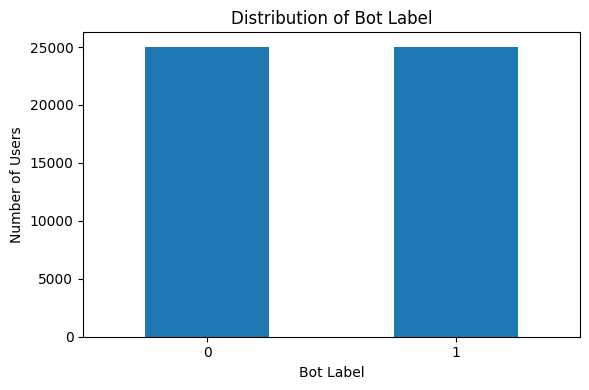

In [12]:
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Distribution of Bot Label")
plt.xlabel("Bot Label")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "label_distribution.png", dpi=300)
plt.show()

**Nhận xét:**  

Phân bố nhãn trong dataset gần như cân bằng:

```text
Human: khoảng 49.96%
Bot: khoảng 50.04%
```

Đây là điểm thuận lợi cho bước đánh giá sau gom nhóm, vì dữ liệu không bị lệch quá mạnh về một lớp.  
Tuy nhiên, trong quá trình huấn luyện K-Means, cột `Bot Label` sẽ không được đưa vào tập đặc trưng.


## 9. Thống kê mô tả các thuộc tính số

Các thuộc tính số chính phản ánh hành vi người dùng gồm:

- `Retweet Count`
- `Mention Count`
- `Follower Count`


In [13]:
numeric_cols = ["Retweet Count", "Mention Count", "Follower Count"]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Retweet Count,50000.0,50.00560,29.181160,0.0,25.00,50.0,75.0,100.0
Mention Count,50000.0,2.51376,1.708563,0.0,1.00,3.0,4.0,5.0
Follower Count,50000.0,4988.60238,2878.742898,0.0,2487.75,4991.5,7471.0,10000.0


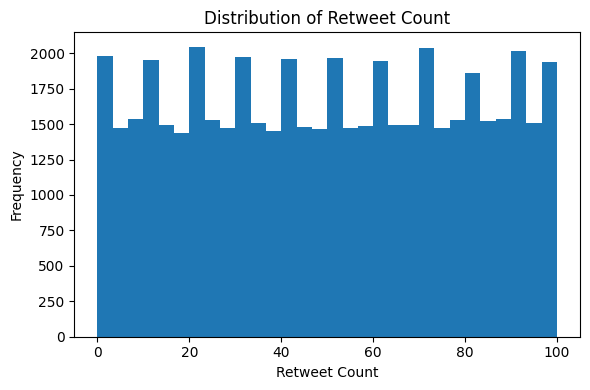

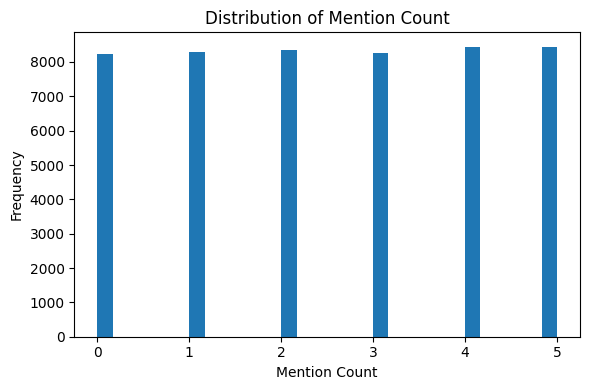

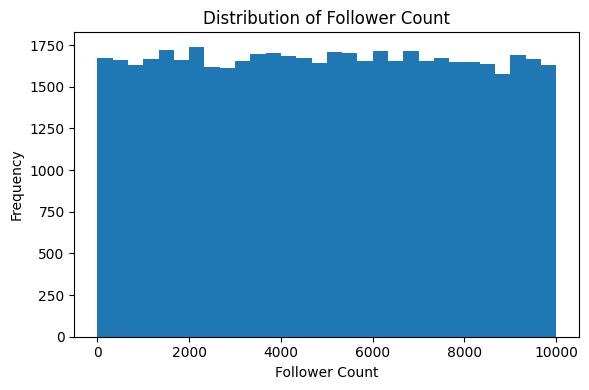

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    output_name = col.lower().replace(" ", "_") + "_distribution.png"
    plt.savefig(FIGURE_DIR / output_name, dpi=300)
    plt.show()

**Nhận xét:**  

Các cột số có thang đo khác nhau:

- `Retweet Count`: dao động từ 0 đến 100.
- `Mention Count`: dao động từ 0 đến 5.
- `Follower Count`: dao động từ 0 đến 10,000.

Do `Follower Count` có thang đo lớn hơn nhiều so với các thuộc tính còn lại, nếu không chuẩn hóa, mô hình gom nhóm có thể bị chi phối bởi thuộc tính này.  
Vì vậy, trước khi chạy K-Means, cần chuẩn hóa dữ liệu bằng `StandardScaler` hoặc `MinMaxScaler`.


## 10. Phân bố trạng thái Verified

Cột `Verified` cho biết tài khoản có được xác minh hay không.  
Khi đưa vào mô hình, cần chuyển:

```text
True  -> 1
False -> 0
```


In [15]:
verified_counts = df["Verified"].value_counts()

verified_summary = pd.DataFrame({
    "count": verified_counts,
    "percent": (verified_counts / len(df) * 100).round(2)
})

verified_summary

,count,percent
Verified,,
True,25004,50.01
False,24996,49.99


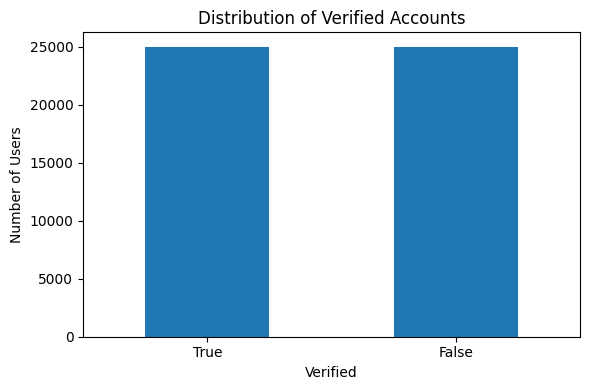

In [16]:
plt.figure(figsize=(6, 4))
verified_counts.plot(kind="bar")
plt.title("Distribution of Verified Accounts")
plt.xlabel("Verified")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "verified_distribution.png", dpi=300)
plt.show()


**Nhận xét:**  

Phân bố `Verified` gần như cân bằng giữa hai nhóm `True` và `False`.  
Đây là một đặc trưng có thể đưa vào mô hình sau khi chuyển đổi sang dạng số.


## 11. Khám phá cột thời gian `Created At`

Cột `Created At` cần được chuyển sang kiểu `datetime`.  
Sau đó có thể dùng để tạo đặc trưng mới như `account_age_days`.


In [17]:
df_time = df.copy()
df_time["Created At"] = pd.to_datetime(df_time["Created At"], errors="coerce")

print("Ngày nhỏ nhất:", df_time["Created At"].min())
print("Ngày lớn nhất:", df_time["Created At"].max())
print("Số giá trị thời gian lỗi:", df_time["Created At"].isnull().sum())


Ngày nhỏ nhất: 2020-01-01 00:44:14
Ngày lớn nhất: 2023-05-31 07:53:27
Số giá trị thời gian lỗi: 0


**Nhận xét:**  

Cột `Created At` có thể chuyển đổi sang dạng thời gian mà không phát sinh lỗi.  
Dữ liệu nằm trong khoảng từ đầu năm 2020 đến cuối tháng 5 năm 2023.

Đặc trưng đề xuất:

```text
account_age_days = ngày mới nhất trong dataset - Created At
```

Đặc trưng này giúp biểu diễn “độ lâu” của tài khoản/bản ghi trong dataset. Với bài toán phát hiện bất thường, một số tài khoản có thời gian tồn tại ngắn nhưng hoạt động mạnh có thể là tín hiệu đáng chú ý.


## 12. Tạo đặc trưng tạm thời để khám phá

Ở bước này chỉ tạo đặc trưng để phân tích EDA, chưa lưu ra file processed.

Các đặc trưng tạm thời gồm:

| Feature | Ý nghĩa |
|---|---|
| `tweet_length` | Độ dài nội dung tweet |
| `username_length` | Độ dài username |
| `hashtag_count` | Số lượng hashtag/cụm hashtag |
| `has_hashtag` | Có hashtag hay không |
| `has_location` | Có location hay không |
| `account_age_days` | Số ngày tính từ `Created At` đến ngày mới nhất trong dataset |


In [18]:
eda_df = df.copy()

eda_df["Created At"] = pd.to_datetime(eda_df["Created At"], errors="coerce")

eda_df["tweet_length"] = eda_df["Tweet"].astype(str).str.len()
eda_df["username_length"] = eda_df["Username"].astype(str).str.len()

eda_df["hashtags_filled"] = eda_df["Hashtags"].fillna("")
eda_df["hashtag_count"] = eda_df["hashtags_filled"].apply(
    lambda x: 0 if str(x).strip() == "" else len(str(x).split())
)
eda_df["has_hashtag"] = (eda_df["hashtag_count"] > 0).astype(int)

eda_df["has_location"] = eda_df["Location"].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == "" else 1
)

reference_date = eda_df["Created At"].max()
eda_df["account_age_days"] = (reference_date - eda_df["Created At"]).dt.days

eda_df[
    [
        "tweet_length",
        "username_length",
        "hashtag_count",
        "has_hashtag",
        "has_location",
        "account_age_days",
    ]
].describe().T


,count,mean,std,min,25%,50%,75%,max
tweet_length,50000.0,62.62734,16.471543,23.0,49.0,62.0,76.0,118.0
username_length,50000.0,9.80378,2.928646,3.0,7.0,9.0,12.0,21.0
hashtag_count,50000.0,2.50026,1.709368,0.0,1.0,2.0,4.0,5.0
has_hashtag,50000.0,0.83318,0.372819,0.0,1.0,1.0,1.0,1.0
has_location,50000.0,1.00000,0.000000,1.0,1.0,1.0,1.0,1.0
account_age_days,50000.0,623.57016,360.836316,0.0,312.0,621.0,938.0,1246.0


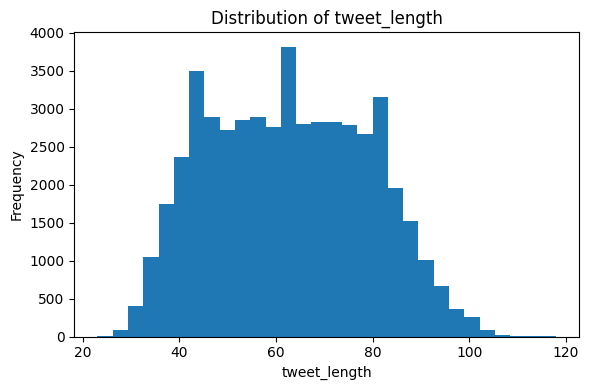

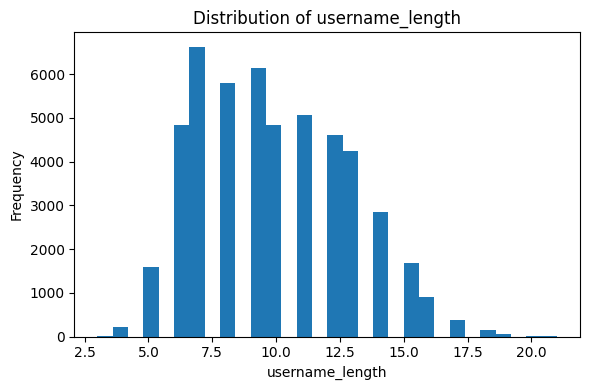

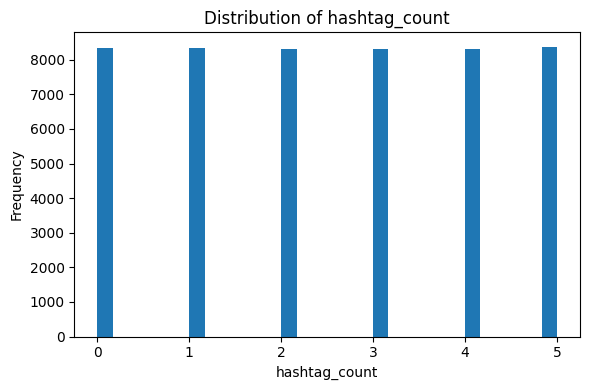

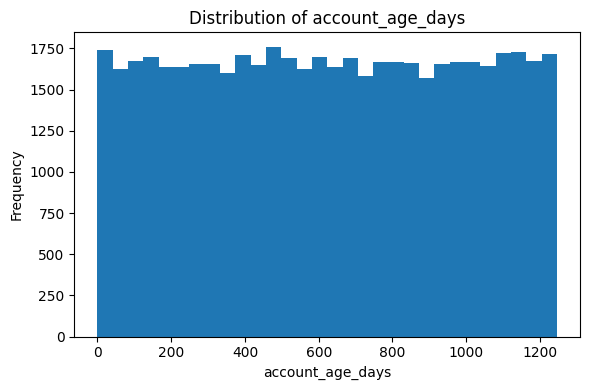

In [19]:
eda_features_to_plot = [
    "tweet_length",
    "username_length",
    "hashtag_count",
    "account_age_days"
]

for col in eda_features_to_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(eda_df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{col}_distribution.png", dpi=300)
    plt.show()


**Nhận xét:**  

Các đặc trưng mới giúp mô tả thêm hành vi và đặc điểm tài khoản:

- `tweet_length`: biểu diễn độ dài nội dung tweet.
- `username_length`: biểu diễn độ dài tên tài khoản.
- `hashtag_count`: biểu diễn mức độ sử dụng hashtag.
- `account_age_days`: biểu diễn độ lâu của bản ghi/tài khoản theo thời gian.

Cột `has_location` trong dataset này có giá trị bằng 1 cho toàn bộ bản ghi, nên không tạo ra khả năng phân biệt giữa các người dùng. Vì vậy, có thể cân nhắc loại bỏ `has_location` khỏi tập đặc trưng dùng cho clustering.


## 13. So sánh đặc trưng theo nhãn Bot/Human

Phần này chỉ nhằm mục đích khám phá dữ liệu.  
Không sử dụng `Bot Label` trong quá trình gom nhóm.


In [20]:
compare_cols = [
    "Retweet Count",
    "Mention Count",
    "Follower Count",
    "tweet_length",
    "username_length",
    "hashtag_count",
    "account_age_days"
]

eda_df.groupby("Bot Label")[compare_cols].mean().round(2)


,Retweet Count,Mention Count,Follower Count,tweet_length,username_length,hashtag_count,account_age_days
Bot Label,,,,,,,
0,49.97,2.53,4985.26,62.61,9.81,2.51,623.21
1,50.04,2.50,4991.94,62.64,9.80,2.50,623.93


In [21]:
eda_df.groupby("Bot Label")[compare_cols].median().round(2)


,Retweet Count,Mention Count,Follower Count,tweet_length,username_length,hashtag_count,account_age_days
Bot Label,,,,,,,
0,50.0,3.0,5007.5,62.0,9.0,3.0,623.0
1,50.0,3.0,4978.0,62.0,9.0,2.0,619.0


**Nhận xét:**  

Trung bình và trung vị của các đặc trưng giữa nhóm `Human` và `Bot` không chênh lệch quá rõ ràng.  
Điều này cho thấy bài toán phát hiện bot/hành vi bất thường bằng các đặc trưng đơn giản có thể không dễ tách tuyến tính.

Vì vậy, việc sử dụng kỹ thuật gom nhóm như K-Means là hợp lý để tìm các nhóm hành vi tương đồng hoặc các điểm nằm xa cụm chính.


## 14. Ma trận tương quan giữa các đặc trưng

Kiểm tra tương quan giúp đánh giá mức độ liên hệ giữa các thuộc tính số.

Lưu ý: `has_location` có giá trị không đổi nên có thể tạo ra giá trị `NaN` trong ma trận tương quan.


In [22]:
corr_cols = [
    "Retweet Count",
    "Mention Count",
    "Follower Count",
    "Verified",
    "tweet_length",
    "username_length",
    "hashtag_count",
    "has_location",
    "account_age_days",
]

corr = eda_df[corr_cols].corr(numeric_only=True)

corr


,Retweet Count,Mention Count,Follower Count,Verified,tweet_length,username_length,hashtag_count,has_location,account_age_days
Retweet Count,1.000000,-0.000020,-0.007624,0.006486,-0.000524,0.002305,-0.005844,NaN,0.003375
Mention Count,-0.000020,1.000000,0.003265,0.006156,-0.005080,0.001813,-0.003141,NaN,0.006326
Follower Count,-0.007624,0.003265,1.000000,0.000357,-0.009347,0.002073,0.006823,NaN,0.007851
Verified,0.006486,0.006156,0.000357,1.000000,0.000726,-0.000925,0.004622,NaN,-0.000913
tweet_length,-0.000524,-0.005080,-0.009347,0.000726,1.000000,0.007896,-0.001228,NaN,-0.000874
username_length,0.002305,0.001813,0.002073,-0.000925,0.007896,1.000000,0.002969,NaN,-0.001682
hashtag_count,-0.005844,-0.003141,0.006823,0.004622,-0.001228,0.002969,1.000000,NaN,-0.002090
has_location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_age_days,0.003375,0.006326,0.007851,-0.000913,-0.000874,-0.001682,-0.002090,NaN,1.000000


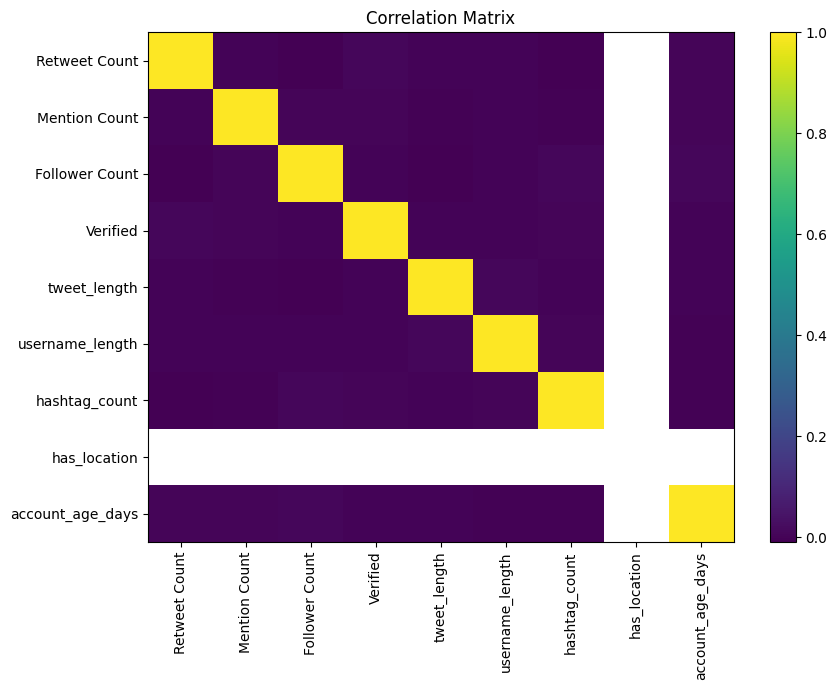

In [23]:
plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_matrix.png", dpi=300)
plt.show()


**Nhận xét:**  

Ma trận tương quan giúp kiểm tra xem các đặc trưng có bị trùng lặp thông tin hay không.  
Trong dataset này, các đặc trưng hành vi cơ bản không thể hiện tương quan quá mạnh với nhau. Điều này cho phép giữ lại nhiều đặc trưng khác nhau để mô tả hành vi người dùng.

Riêng `has_location` là đặc trưng hằng số trong dataset hiện tại, nên không nên ưu tiên dùng cho clustering.


## 15. Đề xuất tập đặc trưng cho bước tiếp theo

Sau khi khám phá dữ liệu, tập đặc trưng có thể dùng cho bước tiền xử lý và gom nhóm gồm:

```text
retweet_count
mention_count
follower_count
verified
tweet_length
username_length
hashtag_count
has_hashtag
account_age_days
```

Cột nên cân nhắc loại bỏ:

```text
has_location
```

Lý do: trong dataset hiện tại, `Location` không bị thiếu ở toàn bộ bản ghi, nên `has_location` luôn bằng 1 và không giúp phân biệt người dùng.

Cột không dùng làm đặc trưng huấn luyện:

```text
bot_label
```

Lý do: đây là nhãn thật, chỉ dùng để đánh giá kết quả sau gom nhóm.


## 16. Kết luận bước khám phá dữ liệu

Qua bước khám phá dữ liệu, có thể rút ra một số nhận xét chính:

1. Dataset gồm **50,000 bản ghi** và **11 thuộc tính**.
2. Dữ liệu không có dòng trùng lặp và không có `User ID` bị lặp.
3. Hầu hết các cột không bị thiếu dữ liệu, ngoại trừ `Hashtags` thiếu khoảng **16.68%**.
4. Phân bố nhãn `Bot Label` gần như cân bằng giữa hai nhóm `Human` và `Bot`.
5. Các thuộc tính số có thang đo khác nhau, đặc biệt `Follower Count` lớn hơn nhiều so với `Retweet Count` và `Mention Count`.
6. Cột `Created At` có thể chuyển đổi tốt sang kiểu thời gian và có thể dùng để tạo `account_age_days`.
7. Có thể tạo thêm các đặc trưng hành vi như `tweet_length`, `username_length`, `hashtag_count`, `has_hashtag`.
8. Cột `has_location` không hữu ích trong dataset hiện tại vì tất cả bản ghi đều có location.
9. Trước khi chạy K-Means, cần đổi tên cột, xử lý missing value, chuyển đổi kiểu dữ liệu và chuẩn hóa các đặc trưng số.

Bước tiếp theo của project là notebook:

```text
02_preprocessing_feature_engineering.ipynb
```

Trong notebook tiếp theo, dữ liệu sẽ được làm sạch, đổi tên cột, tạo đặc trưng chính thức và lưu ra file:

```text
datasets/processed/user_features_with_label.csv
```
